In [1]:
import eval_help as help
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
import matplotlib.patches as mpatches

In [8]:
tag = "parallel2025-06-05_22-56-48"
parent_dir = os.path.dirname(os.getcwd())
density_profiles_dir = os.path.join(parent_dir, "Density_profiles",tag)
pos_profiles_dir = os.path.join(parent_dir, "Positions",tag)
dens_names= [f for f in os.listdir(density_profiles_dir) if os.path.isfile(os.path.join(density_profiles_dir, f))]

pos_dir_names= [f for f in os.listdir(pos_profiles_dir) if os.path.isdir(os.path.join(pos_profiles_dir, f))]
# Parameters
print("pos_dir_names", pos_dir_names)
pos_current_dir = os.path.join(pos_profiles_dir, pos_dir_names[0])
data_files = sorted([f for f in os.listdir(pos_current_dir) if os.path.isfile(os.path.join(pos_current_dir, f))],key=lambda x: int(x.split('step')[1].split('.')[0]))  # Adjust path as needed
print("data_files", data_files)

pos_dir_names ['3', '2', '1']
data_files ['positions_step50000.dat', 'positions_step100000.dat', 'positions_step150000.dat', 'positions_step200000.dat', 'positions_step250000.dat', 'positions_step300000.dat', 'positions_step350000.dat', 'positions_step400000.dat', 'positions_step450000.dat', 'positions_step500000.dat', 'positions_step550000.dat', 'positions_step600000.dat', 'positions_step650000.dat', 'positions_step700000.dat', 'positions_step750000.dat', 'positions_step800000.dat', 'positions_step850000.dat', 'positions_step900000.dat', 'positions_step950000.dat', 'positions_step1000000.dat', 'positions_step1050000.dat', 'positions_step1100000.dat', 'positions_step1150000.dat', 'positions_step1200000.dat', 'positions_step1250000.dat', 'positions_step1300000.dat', 'positions_step1350000.dat', 'positions_step1400000.dat', 'positions_step1450000.dat', 'positions_step1500000.dat', 'positions_step1550000.dat', 'positions_step1600000.dat', 'positions_step1650000.dat', 'positions_step170000

Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/parallel2025-06-05_22-56-48/rho_MC_2D_1.dat


1280
Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/parallel2025-06-05_22-56-48/rho_MC_2D_3.dat
1280
Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/parallel2025-06-05_22-56-48/rho_MC_2D_2.dat
1280


/home/hagen/miniconda3/envs/basic_np/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


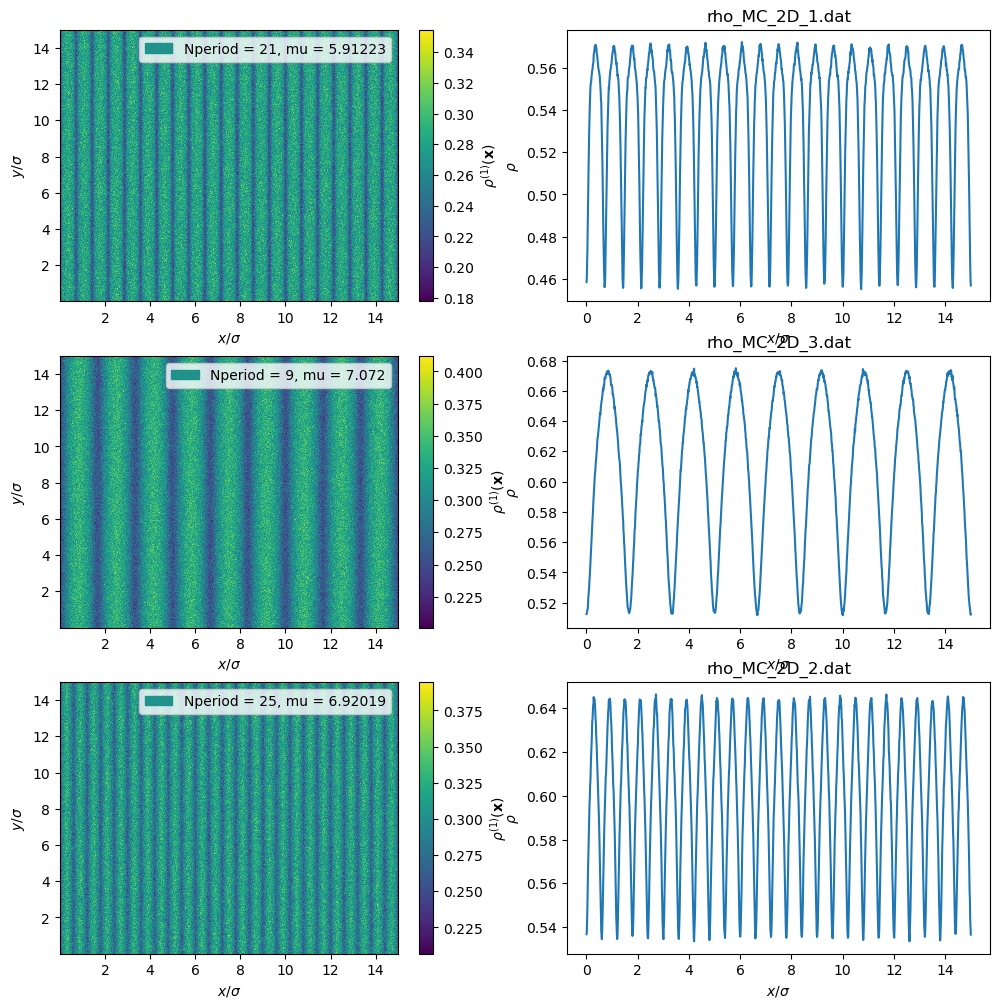

In [10]:

rows = len(dens_names)
fig, axs = plt.subplots(rows,2,figsize=(12, 12))
for i in range(rows):
    df,extra = help.load_df(dens_names[i],tag)
    period = extra[0]
    mu = extra[1]


    shape = np.sqrt(len(df)).astype(int)
    print(shape)
    xi = df["x"].values.reshape(shape, shape)
    yi = df["y"].values.reshape(shape,shape)
    rho = df["rho"].values.reshape(shape,shape)
    pcm = axs[i,0].pcolormesh(xi, yi, rho/2, shading='auto', cmap='viridis',label=f"Nperiod = {period}, mu = {mu}")
    axs[i,0].set_xlabel(r"$x/\sigma$")
    axs[i,0].set_ylabel(r"$y/\sigma$")
    label = f"Nperiod = {period}, mu = {mu}"
    patch = mpatches.Patch(color=pcm.cmap(0.5), label=label)
    axs[i,0].legend(handles=[patch])

    x_values = df.groupby("x").mean().reset_index()["x"]
    rho_values = df.groupby("x").mean().reset_index()["rho"]

    axs[i,1].plot(x_values, rho_values, label="rho")
    axs[i,1].set_title(dens_names[i])
    axs[i,1].set_xlabel(r"$x/\sigma$")
    axs[i,1].set_ylabel(r"$\rho$")



    fig.colorbar(pcm, ax=axs[i,0], label=r"$\rho^{(1)}(\mathbf{x})$")

Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/big_set/rho_MC_2D_121.dat


No packing
No amp
1280
Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/big_set/rho_MC_2D_108.dat
No packing
No amp
1280
Reading file:  /home/hagen/Documents/master_project/Project/Data_generation/Density_profiles/big_set/rho_MC_2D_128.dat
No packing
No amp
1280


/home/hagen/miniconda3/envs/basic_np/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


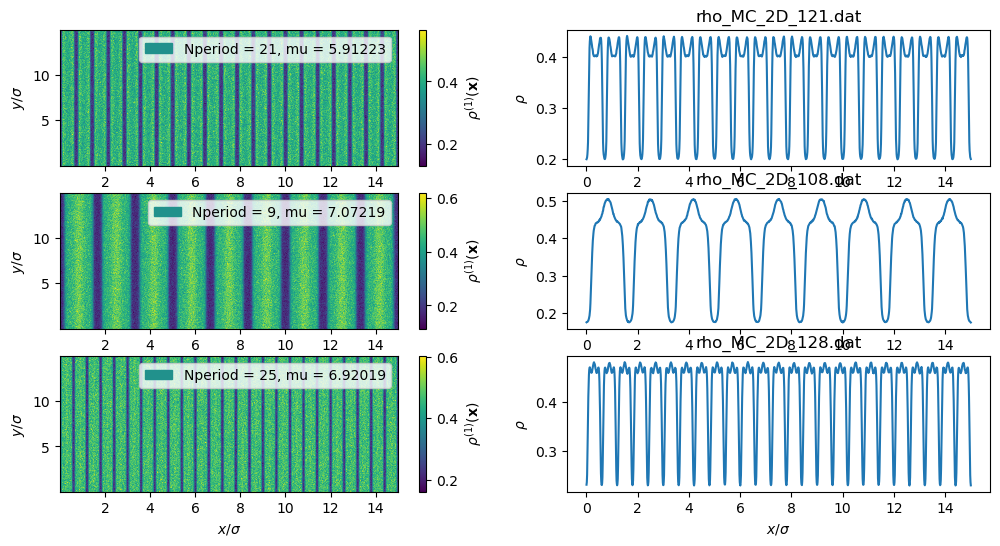

In [ ]:
tag = "big_set"
parent_dir = os.path.dirname(os.getcwd())
density_profiles_dir = os.path.join(parent_dir, "Density_profiles",tag)
dens_names= ["rho_MC_2D_121.dat","rho_MC_2D_108.dat","rho_MC_2D_128.dat"]

# Parameters
rows = len(dens_names)
fig, axs = plt.subplots(rows,2,figsize=(12, 12))
for i in range(rows):
    df,extra = help.load_df(dens_names[i],tag)
    period = extra[0]
    mu = extra[1]

    shape = np.sqrt(len(df)).astype(int)
    print(shape)
    xi = df["x"].values.reshape(shape, shape)
    yi = df["y"].values.reshape(shape,shape)
    rho = df["rho"].values.reshape(shape,shape)
    pcm = axs[i,0].pcolormesh(xi, yi, rho, shading='auto', cmap='viridis',label=f"Nperiod = {period}, mu = {mu}")
    axs[i,0].set_xlabel(r"$x/\sigma$")
    axs[i,0].set_ylabel(r"$y/\sigma$")
    label = f"Nperiod = {period}, mu = {mu}"
    patch = mpatches.Patch(color=pcm.cmap(0.5), label=label)
    axs[i,0].legend(handles=[patch])

    x_values = df.groupby("x").mean().reset_index()["x"]
    rho_values = df.groupby("x").mean().reset_index()["rho"]

    axs[i,1].plot(x_values, rho_values, label="rho")
    axs[i,1].set_title(dens_names[i])
    axs[i,1].set_xlabel(r"$x/\sigma$")
    axs[i,1].set_ylabel(r"$\rho$")



    fig.colorbar(pcm, ax=axs[i,0], label=r"$\rho^{(1)}(\mathbf{x})$")



In [9]:
# Load all data frames in order
radius = 0.5
all_frames = [pd.read_csv(os.path.join(pos_current_dir,file),header=None,names=["part","x","y"],sep=" ") for file in data_files]
# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect('equal')
x_min = all_frames[0]['x'].min() - radius
x_max = all_frames[0]['x'].max() + radius
y_min = all_frames[0]['y'].min() - radius
y_max = all_frames[0]['y'].max() + radius
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
# Initialize empty list to store circle patches
current_circles = []

def init():
    """Initialize the first frame."""
    global current_circles
    for c in current_circles:
        c.remove()
    current_circles = []
    return []

def update(frame_idx):
    global current_circles
    for c in current_circles:
        c.remove()
    current_circles = []
    frame = all_frames[frame_idx]
    for _, row in frame.iterrows():
        c = plt.Circle((row['x'], row['y']), radius, color='blue', alpha=0.6)
        ax.add_patch(c)
        current_circles.append(c)
    # Return the list of artists to redraw; here it’s ax.patches
    return current_circles

# Create animation
ani = FuncAnimation(fig, update, frames=len(all_frames), init_func=init, blit=False)

# To display in Jupyter Notebook
plt.title('Hard Sphere Liquid Animation')
writer = PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
ani.save('scatter.gif', writer=writer)


: 